Dataset Shape: (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

After removing duplicates: (45211, 17)


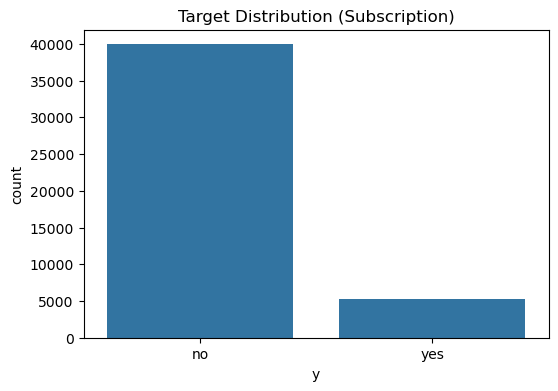

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


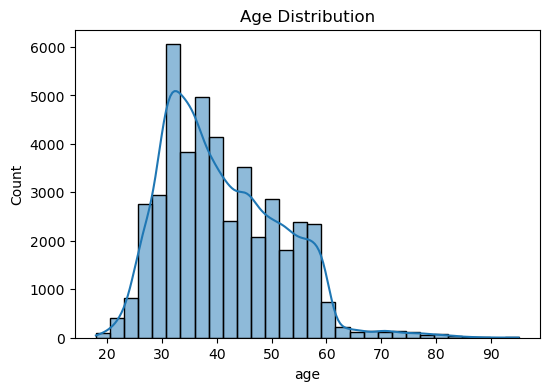

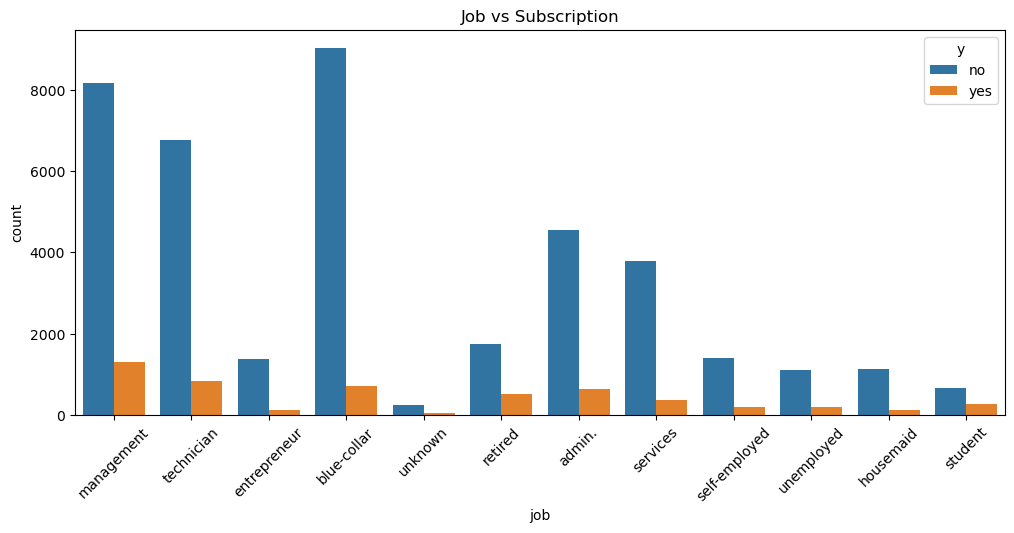


Encoded dataset preview:
   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    4        1          2        0     2143        1     0        2   
1   44    9        2          1        0       29        1     0        2   
2   33    2        1          1        0        2        1     1        2   
3   47    1        1          3        0     1506        1     0        2   
4   33   11        2          3        0        1        0     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  y  
0    5      8       261         1     -1         0         3  0  
1    5      8       151         1     -1         0         3  0  
2    5      8        76         1     -1         0         3  0  
3    5      8        92         1     -1         0         3  0  
4    5      8       198         1     -1         0         3  0  

Train shape: (36168, 16)
Test shape: (9043, 16)

===== LOGISTIC REGRESSION =====
F1 Score: 0.3154269972451791
    

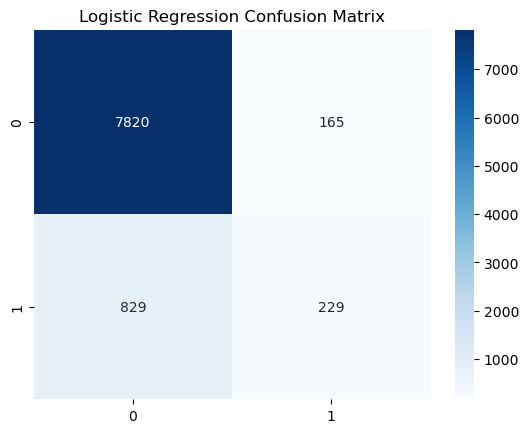

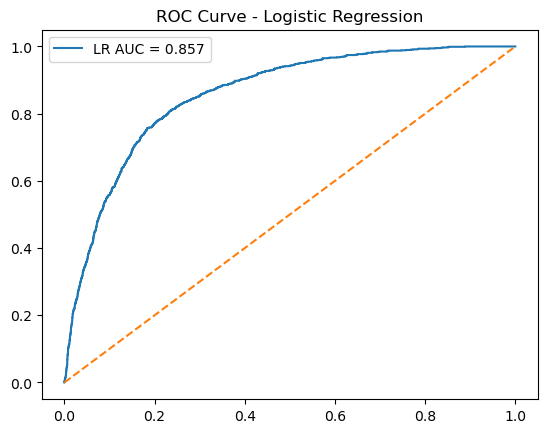


===== RANDOM FOREST =====
F1 Score: 0.5005834305717619
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.65      0.41      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.72      9043
weighted avg       0.89      0.91      0.90      9043



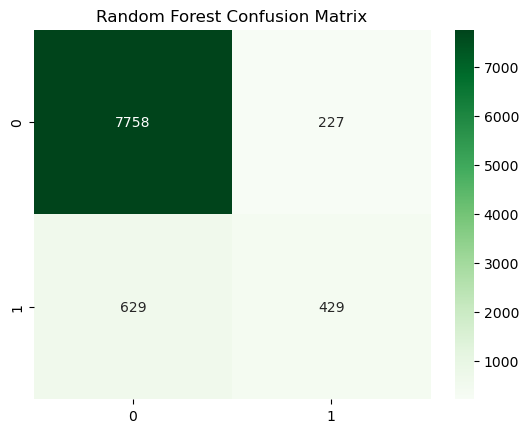

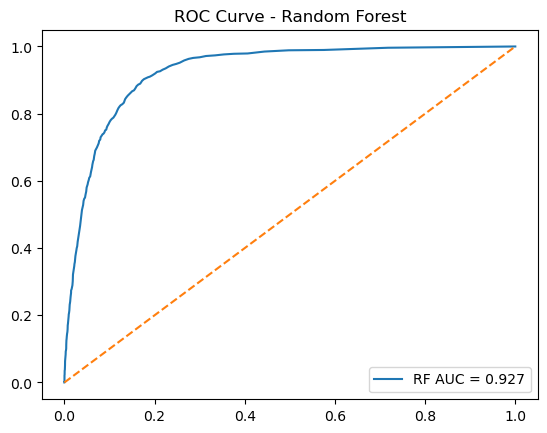


MODEL COMPARISON:
                 Model  F1 Score   ROC AUC
0  Logistic Regression  0.315427  0.856888
1        Random Forest  0.500583  0.927050

Top Features:
      Feature  Importance
11   duration    0.292823
5     balance    0.109880
0         age    0.103779
9         day    0.090144
10      month    0.087234
15   poutcome    0.053442
13      pdays    0.048938
1         job    0.048624
12   campaign    0.038628
3   education    0.027604


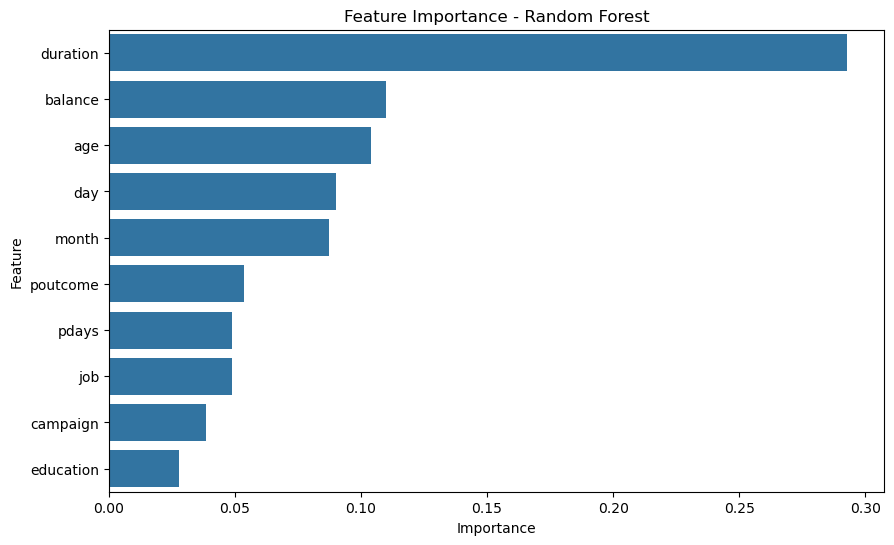


SAMPLE PREDICTION EXPLANATIONS

--------------------------------------------------
Sample: 1
Actual: 0
Predicted: 0
Probability of Subscription: 0.0
--------------------------------------------------
Sample: 2
Actual: 0
Predicted: 0
Probability of Subscription: 0.0
--------------------------------------------------
Sample: 3
Actual: 0
Predicted: 0
Probability of Subscription: 0.005
--------------------------------------------------
Sample: 4
Actual: 0
Predicted: 0
Probability of Subscription: 0.005
--------------------------------------------------
Sample: 5
Actual: 0
Predicted: 0
Probability of Subscription: 0.035

================ FINAL CONCLUSION ================
Best Model: Random Forest
Random Forest captures non-linear patterns better.
Model can help bank target potential customers efficiently.


In [1]:
# TASK 1: TERM DEPOSIT SUBSCRIPTION PREDICTION
# FULL END-TO-END MACHINE LEARNING PIPELINE
# ----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    roc_auc_score
)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

# ----------------------------
# 2. LOAD DATASET
# ----------------------------
df = pd.read_csv(r"G:\bank-full.csv\bank-full.csv", sep=";")

print("Dataset Shape:", df.shape)
print(df.head())

# ----------------------------
# 3. DATA CLEANING
# ----------------------------
df.drop_duplicates(inplace=True)

print("\nAfter removing duplicates:", df.shape)

# ----------------------------
# 4. EDA (EXPLORATORY DATA ANALYSIS)
# ----------------------------

# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title("Target Distribution (Subscription)")
plt.show()

print(df['y'].value_counts(normalize=True) * 100)

# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Job vs subscription
plt.figure(figsize=(12,5))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title("Job vs Subscription")
plt.show()

# ----------------------------
# 5. ENCODE CATEGORICAL FEATURES
# ----------------------------
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

print("\nEncoded dataset preview:")
print(df.head())

# ----------------------------
# 6. SPLIT DATA
# ----------------------------
X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ============================================================
# 7. LOGISTIC REGRESSION MODEL
# ============================================================
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("\n===== LOGISTIC REGRESSION =====")
print("F1 Score:", f1_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.plot(fpr, tpr, label=f"LR AUC = {auc_lr:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

# ============================================================
# 8. RANDOM FOREST MODEL
# ============================================================
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("\n===== RANDOM FOREST =====")
print("F1 Score:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.plot(fpr, tpr, label=f"RF AUC = {auc_rf:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

# ============================================================
# 9. MODEL COMPARISON
# ============================================================
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "F1 Score": [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    "ROC AUC": [auc_lr, auc_rf]
})

print("\nMODEL COMPARISON:")
print(results)

# ============================================================
# 10. FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================================
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:")
print(importances.head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=importances.head(10), x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest")
plt.show()

# ============================================================
# 11. PREDICTION EXPLANATION (5 SAMPLES)
# ============================================================
print("\nSAMPLE PREDICTION EXPLANATIONS\n")

for i in range(5):
    sample = X_test.iloc[i]
    pred = rf.predict([sample])[0]
    prob = rf.predict_proba([sample])[0][1]
    actual = y_test.iloc[i]

    print("-"*50)
    print("Sample:", i+1)
    print("Actual:", actual)
    print("Predicted:", pred)
    print("Probability of Subscription:", round(prob, 4))

# ============================================================
# 12. FINAL CONCLUSION
# ============================================================
best = "Random Forest" if f1_score(y_test, y_pred_rf) > f1_score(y_test, y_pred_lr) else "Logistic Regression"

print("\n================ FINAL CONCLUSION ================")
print("Best Model:", best)
print("Random Forest captures non-linear patterns better.")
print("Model can help bank target potential customers efficiently.")
print("==================================================")